# Density functional theory optimized effective potential method

![Status](https://img.shields.io/static/v1.svg?label=Status&message=Finished&color=green)

**Author:** Egor Trushin  
**Date created:**  21/07/2025  
**Last modified:**  31/03/2026

## 1. Introduction

In this tutorial, I will present examples of density functional theory (DFT) optimized effective potential (OEP) calculations. These examples are intended to illustrate the main functionality and post-processing of calculations, such as plotting of resulting exchange-correlation potentials, accessing eigenvalues, etc.

---

The present DFT-OEP method for closed-shell system is described in
> E. Trushin, A. Görling. Improving Exchange-Correlation Potentials of Standard Density Functionals with the Optimized-Effective-Potential Method for Higher Accuracy of Excitation Energies - J. Chem. Theory Comput. 2025, 21, 4, 1667–1683. [link](https://doi.org/10.1021/acs.jctc.4c01477)

The implementation of this method is heavily based on the implementation of the exact-exchange (EXX) OEP method presented in
> E. Trushin, A. Görling. Numerically stable optimized effective potential method with standard Gaussian basis sets - J. Chem. Phys. 155 (2021) 054109. [link](https://doi.org/10.1063/5.0056431)

The implementation of the DFT-OEP method for open-shell systems is heavily based on the corresponding implementation of the EXX-OEP method presented in
> E. Trushin, A. Görling. Avoiding spin contamination and spatial symmetry breaking by exact-exchange-only optimized-effective-potential methods within the symmetrized Kohn-Sham framework - J. Chem. Phys. 159 (2023) 244109. [link](https://doi.org/10.1063/5.0171546)

---

<div class="alert alert-block alert-info"> <b>Important:</b> Read carefully the information below about the selection of basis sets and the thr_fai_oep parameter. </div>

DFT-OEP calculations requires to specify two basis sets, namely orbital and OEP basis sets. If density fitting is employed, the corresponding basis sets have to be also specified. The orbital basis set is the primary basis set for e.g. the representation of orbitals and the calculation of energy contributions. The OEP basis set is the auxiliary basis set for representing e.g. the exchange potential. 
Gaussian basis set OEP methods for a long time suffered from numerical instabilities resulting from problems in balancing the orbital basis sets with the auxiliary basis sets.
Present implementation uses a preprocessing of the auxiliary basis that enables such balancing in an automatic fashion for standard Gaussian basis sets.
The preprocessing step removes linear combinations of auxiliary basis functions that couple poorly to products of occupied times unoccupied Kohn-Sham orbitals. It involves the threshold `thr_fai_oep`, which determines how many linear combinations of auxiliary basis functions are removed and varies with respect to the size of the orbital basis set used. This scheme was tested using Dunning correlation consistent basis sets aug-cc-pwCVXZ (X = T, Q, 5) and recommended thresholds are

| Orbital basis set | **thr_fai_oep** |
| :----: | :----: |
| aug-cc-pwCVTZ  | $5 \cdot 10^{-2}$   |
| aug-cc-pwCVQZ  | $1.7 \cdot 10^{-2}$ |
| aug-cc-pwCV5Z  | $5 \cdot 10^{-3}$   |

These thresholds are also expected to work for orbital basis sets without augmentation cc-pwCVXZ (X = T, Q, 5) and without core-polarization functions aug-cc-pVXZ (X = T, Q, 5).

As an auxiliary basis set (OEP), the aug-cc-pVXZ/mp2fit (X=T,Q,5) family of basis sets is recommended. In particular, it is recommended to use the aug-cc-pVDZ/mp2fit auxiliary basis sets for atoms up to neon and the aug-cc-pVTZ/mp2fit auxiliary basis sets for heavier atoms.

Def2 basis sets of Ahlrichs family of similar quality also might work, but were not tested extensively in practice.

---

Let's start with the import of the required libraries and functions.

In [1]:
import time
from pyscf import dft, gto, tddft
from methods.dftoep import DFTOEP
from methods.osdftoep import OSDFTOEP
from utils.eval_pot import eval_pot
from utils.gen_coords_1d import gen_coords_1d
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["figure.figsize"] = (5, 4)

## 2. Calculations for closed-shell systems

### 2.1 CO molecule
We start with the DFT-OEP calculation of the closed-shell molecule, CO. We will plot the resulting exchange potentials along the bond axis, including its reference and reminder parts. 

In [2]:
# basis sets, to be used for all systems
ORBITAL_BASIS = "aug-cc-pwCVQZ"
OEP_BASIS = "aug-cc-pVDZ-RIFIT"
DFIT_BASIS = "aug-cc-pwCV5Z-RIFIT"

# geometry
GEOM = "C 0.000000    0.000000   -0.646514; O 0.000000    0.000000    0.484886"

# create mol object
mol = gto.M(atom=GEOM, basis=ORBITAL_BASIS)
mol.verbose = 0
mol.symmetry = False

In [3]:
# run DFT calculation with PBE0 functional
mf = dft.RKS(mol, "PBE0").density_fit(auxbasis=DFIT_BASIS).run()

# run DFT-OEP calculation
mf_oep = DFTOEP(mf, OEP_BASIS)
mf_oep.run(maxit=15, thr_fai_oep=1.7e-2)

ITER        ENERGY               EDIFF
  0   -113.235577781679
  1   -113.235580748342     -0.000002966663
  2   -113.235580458655      0.000000289687
  3   -113.235581585560     -0.000001126906
  4   -113.235581591065     -0.000000005505
SCF converged


In the end, we have the access to the reference $v_{xc}^{ref}$, rest $v_{xc}^{rest}$ and full $v_{xc}$ exchange-correlation potentials. Let's plot the potentials.

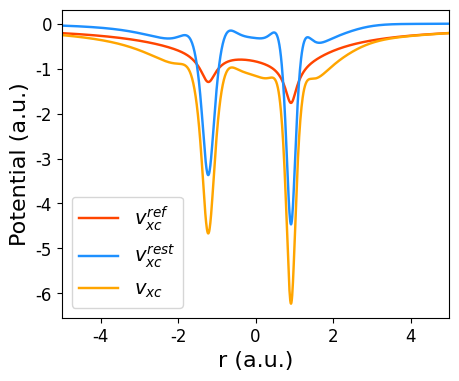

In [4]:
coords = gen_coords_1d(-5.0, 5.0, 1000)
vrest_on_grid = eval_pot(mf_oep.pmol, coords, mf_oep.vrest_oep)
vref_on_grid = eval_pot(mf_oep.pmol, coords, mf_oep.vref_oep)
vx_on_grid = eval_pot(mf_oep.pmol, coords, mf_oep.vrest_oep + mf_oep.vref_oep)

plt.plot(coords[:, 2], vref_on_grid, color="orangered", label="$v_{xc}^{ref}$")
plt.plot(coords[:, 2], vrest_on_grid, color="dodgerblue", label="$v_{xc}^{rest}$")
plt.plot(coords[:, 2], vx_on_grid, color="orange", label="$v_{xc}$")
plt.xlim(-5, 5)
plt.ylabel("Potential (a.u.)", fontsize=16)
plt.xlabel("r (a.u.)", fontsize=16)
plt.legend()
plt.show()

Let's print eigenvalues, HOMO energy, and LUMO-HOMO gap.

In [5]:
# Function to make text in bold
def bold_text(text): return "\033[1m" + text + "\033[0m"

def print_eigs(eigs, no, nmax):
    """Function to print eigenvalues, HOMO energy, and LUMO-HOMO gap.
    
    Args:
      eig: Eigenvalues.
      no: Number of occupied orbitals.
      nmax: Number of eigenvalues to print.
    """
    if len(eigs.shape) == 1:  # closed-shell case
        for i in range(nmax):
            eig = f"{eigs[i]:7.3f}"
            if i+1 <= no:
                eig = bold_text(eig)
            print(f"{i+1:2}   {eig}")
        print(f"HOMO:      {eigs[no-1]:7.3f}")
        print(f"LUMO-HOMO: {eigs[no]-eigs[no-1]:7.3f}")
    else:
        for i in range(nmax):
            ea = f"{eigs[0, i]:7.3f}"
            eb = f"{eigs[1, i]:7.3f}"
            if i+1 <= no[0]: 
                ea = bold_text(ea)
            if i+1 <= no[1]:
                eb = bold_text(eb)            
            if i+1 <= nmax:
                print(f"{i+1:2}   {ea}  {eb}")
        print(f"HOMO:       {eigs[0, no[0]-1]:7.3f}   {eigs[1, no[1]-1]:7.3f}")
        print(f"LUMO-HOMO:  {eigs[0, no[0]] - eigs[0, no[0] - 1]:7.3f}   {eigs[1, no[1]] - eigs[1, no[1] - 1]:7.3f}")

In [6]:
print_eigs(mf_oep.mf.mo_energy, mf_oep.nelec, 10)

 1   -18.978
 2   -10.132
 3    -1.225
 4    -0.664
 5    -0.576
 6    -0.576
 7    -0.471
 8    -0.207
 9    -0.207
10    -0.114
HOMO:       -0.471
LUMO-HOMO:   0.264


Eigenvalues corresponding to occupied orbitals are printed in bold.

We can also access the resulting total energy:

In [7]:
print("Total energy:", mf_oep.e_tot)

Total energy: -113.23558159106503


### 2.2 CO molecule with HOMO condition
We can enforce an the so-called HOMO condition:
$$IP = E^{N-1, Frozen}_{x@xc} - E^{N}_{x@xc}$$
where IP is ionization potential, $E^{N}_{x@xc}$ and $E^{N-1, Frozen}_{x@xc}$ are energie of $N$-electron and $(N-1)$-electron systems, respectively, evaluated non-self-consistently using only the exchange part of the exchange-correlation functional (as used in the self-consistent calculation). Enforcing this condition typically leads to significantly imporved HOMO energy.

In [8]:
# run DFT calculation with PBE0 functional
mf = dft.RKS(mol, "PBE0").density_fit(auxbasis=DFIT_BASIS).run()

# run DFT-OEP calculation
mf_oep = DFTOEP(mf, OEP_BASIS, use_HOMO_condition=True, xc_homo="0.25*HF+0.75*GGA_X_PBE")
mf_oep.run(maxit=15, thr_fai_oep=1.7e-2)

ITER        ENERGY               EDIFF
  0   -113.235546369801
  1   -113.235549288798     -0.000002918997
  2   -113.235550509940     -0.000001221142
  3   -113.235551566441     -0.000001056501
  4   -113.235551599438     -0.000000032997
  5   -113.235551595154      0.000000004284
SCF converged


In [9]:
print_eigs(mf_oep.mf.mo_energy, 7, 10)

 1   -19.041
 2   -10.189
 3    -1.284
 4    -0.723
 5    -0.636
 6    -0.636
 7    -0.530
 8    -0.265
 9    -0.265
10    -0.142
HOMO:       -0.530
LUMO-HOMO:   0.265


As might be seen, the HOMO energy is shifted as well as other eigenvalues.

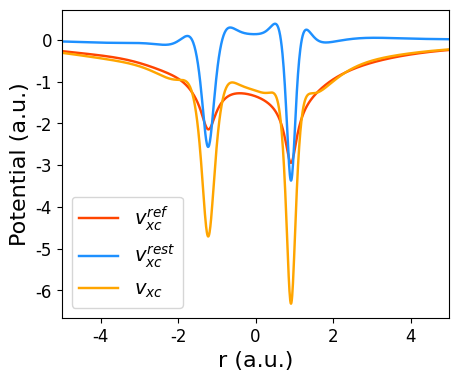

In [10]:
coords = gen_coords_1d(-5.0, 5.0, 1000)
vrest_on_grid = eval_pot(mf_oep.pmol, coords, mf_oep.vrest_oep)
vref_on_grid = eval_pot(mf_oep.pmol, coords, mf_oep.vref_oep)
vx_on_grid = eval_pot(mf_oep.pmol, coords, mf_oep.vrest_oep + mf_oep.vref_oep)

plt.plot(coords[:, 2], vref_on_grid, color="orangered", label="$v_{xc}^{ref}$")
plt.plot(coords[:, 2], vrest_on_grid, color="dodgerblue", label="$v_{xc}^{rest}$")
plt.plot(coords[:, 2], vx_on_grid, color="orange", label="$v_{xc}$")
plt.xlim(-5, 5)
plt.ylabel("Potential (a.u.)", fontsize=16)
plt.xlabel("r (a.u.)", fontsize=16)
plt.legend()
plt.show()

In [11]:
print("Total energy:", mf_oep.e_tot)

Total energy: -113.23555159515377


The exchange-correlation potential of the DFT-OEP method possesses correct $-1/r$ asymptotic decay, in contrast to the commonly used (semi-)local functionals. Let's compare the DFT-OEP exchange-correlation potential with the exchange-correlation potential from an LDA calculation.

In [12]:
coords = gen_coords_1d(-10.0, 10.0, 1000)
vx_on_grid = eval_pot(mf_oep.pmol, coords, mf_oep.vrest_oep + mf_oep.vref_oep)

In [13]:
mf = dft.RKS(mol, xc="LDA_X, LDA_C_VWN_RPA").density_fit().run(conv_tol=1e-14)
dm = mf.make_rdm1()
ao_value = dft.numint.eval_ao(mol, coords, deriv=0)
rho = dft.numint.eval_rho(mol, ao_value, dm, xctype="LDA")
_, vxc_lda = dft.libxc.eval_xc("LDA_X, LDA_C_VWN_RPA", rho)[:2]

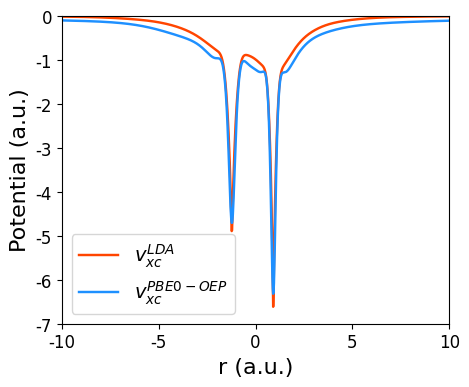

In [14]:
plt.plot(coords[:, 2], vxc_lda[0], color="orangered", label="$v_{xc}^{LDA}$")
plt.plot(coords[:, 2], vx_on_grid, color="dodgerblue", label="$v_{xc}^{PBE0-OEP}$")
plt.xlim(-10, 10)
plt.ylim(-7, 0.01)
plt.ylabel("Potential (a.u.)", fontsize=16)
plt.xlabel("r (a.u.)", fontsize=16)
plt.legend()
plt.show()

### 2.2 TDDFT calculation for CO molecule

In [15]:
# run DFT calculation with PBE0 functional
mf = dft.RKS(mol, "PBE0").density_fit(auxbasis=DFIT_BASIS).run()

# run DFT-OEP calculation
mf_oep = DFTOEP(mf, OEP_BASIS, use_HOMO_condition=True, xc_homo="0.25*HF+0.75*GGA_X_PBE")
mf_oep.run(maxit=15, thr_fai_oep=1.7e-2)

mf_oep.mf.xc="PBE"  # we want to use GGA kernel
td = tddft.TDDFT(mf_oep.mf)
td.nstates = 10
td.kernel()
td.analyze(verbose=10)

ITER        ENERGY               EDIFF
  0   -113.235546369801
  1   -113.235549288798     -0.000002918997
  2   -113.235550509940     -0.000001221142
  3   -113.235551566441     -0.000001056501
  4   -113.235551599438     -0.000000032997
  5   -113.235551595154      0.000000004284
SCF converged

** Singlet excitation energies and oscillator strengths **
Excited State   1:      8.50378 eV    145.80 nm  f=0.0786
       7 -> 8         0.68767
       7 -> 9         0.13200
Excited State   2:      8.50378 eV    145.80 nm  f=0.0786
       7 -> 8         0.13200
       7 -> 9        -0.68767
Excited State   3:     10.08608 eV    122.93 nm  f=0.0000
       5 -> 9        -0.49201
       6 -> 8         0.49201
Excited State   4:     10.40571 eV    119.15 nm  f=0.0000
       5 -> 8        -0.11608
       5 -> 9         0.48628
       6 -> 8         0.48628
       6 -> 9         0.11608
Excited State   5:     10.40572 eV    119.15 nm  f=0.0000
       5 -> 8         0.48628
       5 -> 9         0

## 3. Calculations for open-shell systems

### 3.1 Spin-unrestricted calculation for N atom
A common way to perform Kohn-Sham (KS) calculations for open-shell systems is based on the spin-unrestricted KS method, which uses two different sets of spatial orbitals for $\alpha$ and $\beta$ electrons. This leads to two different effective KS potentials for the $\alpha$- and $\beta$-electrons.

In [16]:
# geomerty
GEOM = "N 0.000000    0.000000  0.000000"

# create mol object
mol = gto.M(atom=GEOM, basis=ORBITAL_BASIS, spin=3)
mol.verbose = 0
mol.symmetry = False

In [17]:
# run DFT calculation
mf = dft.UKS(mol, xc="PBE0").density_fit(auxbasis=DFIT_BASIS).run()

# run DFT-OEP calculation
mf_oep = OSDFTOEP(mf, OEP_BASIS)
mf_oep.run(maxit=30, thr_fai_oep=1.7e-2)

ITER        ENERGY               EDIFF
  0    -54.545719099286
  1    -54.545719969384     -0.000000870097
  2    -54.545719943890      0.000000025494
  3    -54.545719953734     -0.000000009844
SCF converged


In [18]:
print_eigs(mf_oep.mf.mo_energy, mf_oep.nelec, 7)

 1   -14.269  -14.285
 2    -0.910   -0.775
 3    -0.481   -0.362
 4    -0.481   -0.362
 5    -0.481   -0.362
 6    -0.124   -0.114
 7    -0.080   -0.070
HOMO:        -0.481    -0.775
LUMO-HOMO:    0.357     0.413


The electron configuration of N in its ground state is $1s^22s^22p^3$. There are five $\alpha$ occupied orbitals and two $\beta$ occupied orbital. Due to spin symmetry breaking, there are two spin channels with spatially different $\alpha$ and $\beta$ orbitals with different energies. Orbital energies for $\alpha$ and $\beta$ spin channels differ, reflecting spin symmetry breaking, whereas they are the same in a real electronic system.  
Spin contamination appears, as can be seen from the values of the $S^2$ operator deviating from the correct value of 3.75.

In [19]:
print(f"S^2 = {mf_oep.mf.spin_square()[0]:.7f}")

S^2 = 3.7527674


Spin symmetry breaking leads to different exchange potentials for $\alpha$ and $\beta$ spin channels.

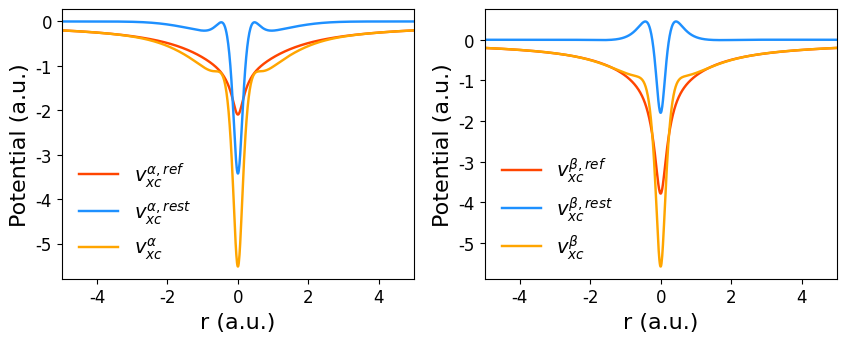

In [20]:
coords = gen_coords_1d(-5.0, 5.0, 1000)
vrest_on_grid_a = eval_pot(mf_oep.pmol, coords, mf_oep.vrest_oep_a)
vref_on_grid_a = eval_pot(mf_oep.pmol, coords, mf_oep.vref_oep_a)
vx_on_grid_a = eval_pot(mf_oep.pmol, coords, mf_oep.vrest_oep_a + mf_oep.vref_oep_a)
vrest_on_grid_b = eval_pot(mf_oep.pmol, coords, mf_oep.vrest_oep_b)
vref_on_grid_b = eval_pot(mf_oep.pmol, coords, mf_oep.vref_oep_b)
vx_on_grid_b = eval_pot(mf_oep.pmol, coords, mf_oep.vrest_oep_b + mf_oep.vref_oep_b)

fig, axs = plt.subplots(1, 2, figsize=(10, 3.5))
axs[0].plot(coords[:, 2], vref_on_grid_a, color="orangered", label="$v_{xc}^{\\alpha, ref}$")
axs[0].plot(coords[:, 2], vrest_on_grid_a, color="dodgerblue", label="$v_{xc}^{\\alpha, rest}$")
axs[0].plot(coords[:, 2], vx_on_grid_a, color="orange", label="$v_{xc}^{\\alpha}$")
axs[0].set_xlim(-5, 5)
axs[0].set_ylabel("Potential (a.u.)", fontsize=16)
axs[0].set_xlabel("r (a.u.)", fontsize=16)
axs[0].legend(frameon=False)
axs[1].plot(coords[:, 2], vref_on_grid_b, color="orangered", label="$v_{xc}^{\\beta, ref}$")
axs[1].plot(coords[:, 2], vrest_on_grid_b, color="dodgerblue", label="$v_{xc}^{\\beta, rest}$")
axs[1].plot(coords[:, 2], vx_on_grid_b, color="orange", label="$v_{xc}^{\\beta}$")
axs[1].set_xlim(-5, 5)
axs[1].set_ylabel("Potential (a.u.)", fontsize=16)
axs[1].set_xlabel("r (a.u.)", fontsize=16)
axs[1].legend(frameon=False)
plt.show()

### 3.2 Spin-restricted calculation for N atom

An alternative approach to the spin-unrestricted KS method is to use one set of spatial orbitals for electrons of both spins. This approach is often referred to as the spin-restricted KS method for open-shell systems. 

In [21]:
# run DFT calculation
mf = dft.UKS(mol, xc="PBE0").density_fit(auxbasis=DFIT_BASIS).run()

# run DFT-OEP calculation
mf_oep = OSDFTOEP(mf, OEP_BASIS, spin_sym=True)
mf_oep.run(maxit=30, thr_fai_oep=1.7e-2)

ITER        ENERGY               EDIFF
  0    -54.543545150126
  1    -54.543569698484     -0.000024548357
  2    -54.543574754704     -0.000005056220
  3    -54.543575071978     -0.000000317275
  4    -54.543575075372     -0.000000003394
SCF converged


In [22]:
print_eigs(mf_oep.mf.mo_energy, mf_oep.nelec, 7)

 1   -14.322  -14.322
 2    -0.900   -0.900
 3    -0.473   -0.473
 4    -0.473   -0.473
 5    -0.473   -0.473
 6    -0.124   -0.124
 7    -0.079   -0.079
HOMO:        -0.473    -0.900
LUMO-HOMO:    0.349     0.426


In contrast to the spin-unrestricted case, the spin-restricted calculation does not exhibit spin symmetry breaking leading to the same orbital energies in $\alpha$ and $\beta$ spin channels.

In [23]:
print(f"S^2 = {mf_oep.mf.spin_square()[0]:.7f}")

S^2 = 3.7500000


The potentials of $\alpha$ and $\beta$ are the same or in other words $\alpha$ and $\beta$ electrons move in the same potential.

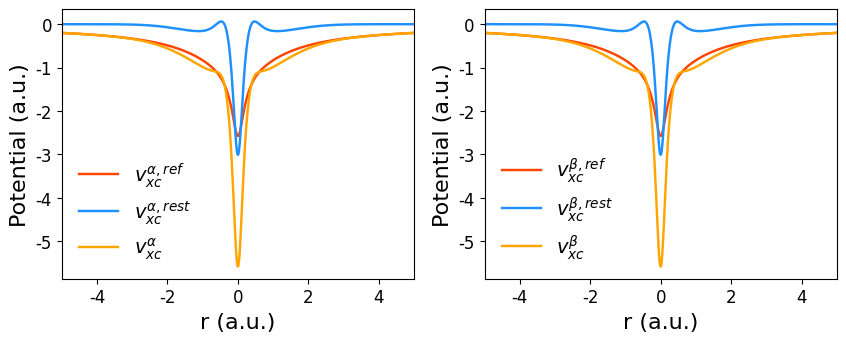

In [24]:
coords = gen_coords_1d(-5.0, 5.0, 1000)
vrest_on_grid_a = eval_pot(mf_oep.pmol, coords, mf_oep.vrest_oep_a)
vref_on_grid_a = eval_pot(mf_oep.pmol, coords, mf_oep.vref_oep_a)
vx_on_grid_a = eval_pot(mf_oep.pmol, coords, mf_oep.vrest_oep_a + mf_oep.vref_oep_a)
vrest_on_grid_b = eval_pot(mf_oep.pmol, coords, mf_oep.vrest_oep_b)
vref_on_grid_b = eval_pot(mf_oep.pmol, coords, mf_oep.vref_oep_b)
vx_on_grid_b = eval_pot(mf_oep.pmol, coords, mf_oep.vrest_oep_b + mf_oep.vref_oep_b)

fig, axs = plt.subplots(1, 2, figsize=(10, 3.5))
axs[0].plot(coords[:, 2], vref_on_grid_a, color="orangered", label="$v_{xc}^{\\alpha, ref}$")
axs[0].plot(coords[:, 2], vrest_on_grid_a, color="dodgerblue", label="$v_{xc}^{\\alpha, rest}$")
axs[0].plot(coords[:, 2], vx_on_grid_a, color="orange", label="$v_{xc}^{\\alpha}$")
axs[0].set_xlim(-5, 5)
axs[0].set_ylabel("Potential (a.u.)", fontsize=16)
axs[0].set_xlabel("r (a.u.)", fontsize=16)
axs[0].legend(frameon=False)
axs[1].plot(coords[:, 2], vref_on_grid_b, color="orangered", label="$v_{xc}^{\\beta, ref}$")
axs[1].plot(coords[:, 2], vrest_on_grid_b, color="dodgerblue", label="$v_{xc}^{\\beta, rest}$")
axs[1].plot(coords[:, 2], vx_on_grid_b, color="orange", label="$v_{xc}^{\\beta}$")
axs[1].set_xlim(-5, 5)
axs[1].set_ylabel("Potential (a.u.)", fontsize=16)
axs[1].set_xlabel("r (a.u.)", fontsize=16)
axs[1].legend(frameon=False)
plt.show()

### 3.3 Spin-unrestricted calculation for C atom

In [25]:
# geomerty
GEOM = "C 0.000000    0.000000  0.000000"

# create mol object
mol = gto.M(atom=GEOM, basis=ORBITAL_BASIS, spin=2)
mol.verbose = 0
mol.symmetry = False

In [26]:
# run DFT calculation
mf = dft.UKS(mol, xc="PBE0").density_fit(auxbasis=DFIT_BASIS).run()

# run DFT-OEP calculation
mf_oep = OSDFTOEP(mf, OEP_BASIS)
mf_oep.run(maxit=30, thr_fai_oep=1.7e-2)

ITER        ENERGY               EDIFF
  0    -37.806742677991
  1    -37.806748987246     -0.000006309256
  2    -37.806748764102      0.000000223144
  3    -37.806748746505      0.000000017598
  4    -37.806748748877     -0.000000002372
SCF converged


In [27]:
print_eigs(mf_oep.mf.mo_energy, mf_oep.nelec, 7)

 1   -10.173  -10.195
 2    -0.686   -0.620
 3    -0.377   -0.351
 4    -0.377   -0.293
 5    -0.357   -0.293
 6    -0.117   -0.112
 7    -0.080   -0.082
HOMO:        -0.377    -0.620
LUMO-HOMO:    0.020     0.269


In [28]:
print(f"S^2 = {mf_oep.mf.spin_square()[0]:.7f}")

S^2 = 2.0031605


The electron configuration of C in its ground state is $1s^22s^22p^2$. There are four $\alpha$ occupied orbitals and two $\beta$ occupied orbital. Due to spin symmetry breaking, there are two spin channels with spatially different $\alpha$ and $\beta$ orbitals with different energies. Orbital energies for $\alpha$ and $\beta$ spin channels differ, reflecting spin symmetry breaking, whereas they are the same in a real electronic system. Furthermore, the energies of the orbitals in the $p$-shell in both spin channels do not exhibit a three-fold degeneracy, but split into a non-degenerate and a doubly degenerate level reflecting a cylindrical instead of spherical space symmetry. This is manifistation of space symmetry breaking.

Spin symmetry breaking leads to different exchange potentials for $\alpha$ and $\beta$ spin channels. Exchange potential also reflects space symmetry breaking - in different directions it differs.

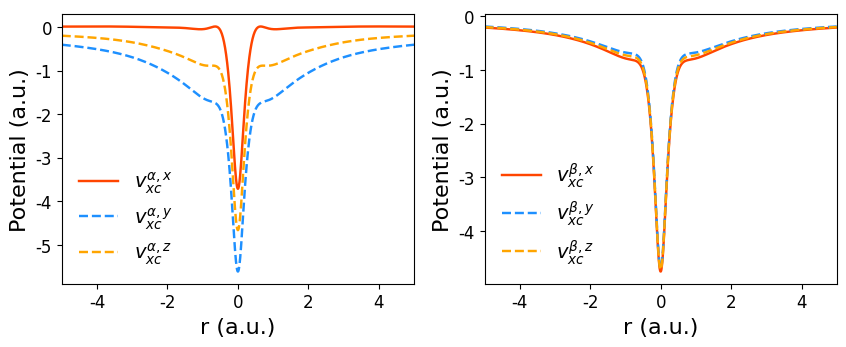

In [29]:
coords_x = gen_coords_1d(-5.0, 5.0, 1000, mode="x")
vx_on_grid_a_x = eval_pot(mf_oep.pmol, coords_x, mf_oep.vrest_oep_a + mf_oep.vref_oep_a)
vx_on_grid_b_x = eval_pot(mf_oep.pmol, coords_x, mf_oep.vrest_oep_b + mf_oep.vref_oep_b)

coords_y = gen_coords_1d(-5.0, 5.0, 1000, mode="y")
vx_on_grid_a_y = eval_pot(mf_oep.pmol, coords_y, mf_oep.vrest_oep_a + mf_oep.vref_oep_a)
vx_on_grid_b_y = eval_pot(mf_oep.pmol, coords_y, mf_oep.vrest_oep_b + mf_oep.vref_oep_b)

coords_z = gen_coords_1d(-5.0, 5.0, 1000)
vx_on_grid_a_z = eval_pot(mf_oep.pmol, coords_z, mf_oep.vrest_oep_a + mf_oep.vref_oep_a)
vx_on_grid_b_z = eval_pot(mf_oep.pmol, coords_z, mf_oep.vrest_oep_b + mf_oep.vref_oep_b)

fig, axs = plt.subplots(1, 2, figsize=(10, 3.5))
axs[0].plot(coords_x[:, 0], vx_on_grid_a_x, color="orangered", label="$v_{xc}^{\\alpha, x}$")
axs[0].plot(coords_y[:, 1], vx_on_grid_a_y, "--", color="dodgerblue", label="$v_{xc}^{\\alpha, y}$")
axs[0].plot(coords_z[:, 2], vx_on_grid_a_z, "--", color="orange", label="$v_{xc}^{\\alpha, z}$")
axs[0].set_xlim(-5, 5)
axs[0].set_ylabel("Potential (a.u.)", fontsize=16)
axs[0].set_xlabel("r (a.u.)", fontsize=16)
axs[0].legend(frameon=False)
axs[1].plot(coords_x[:, 0], vx_on_grid_b_x, color="orangered", label="$v_{xc}^{\\beta, x}$")
axs[1].plot(coords_y[:, 1], vx_on_grid_b_y, "--", color="dodgerblue", label="$v_{xc}^{\\beta, y}$")
axs[1].plot(coords_z[:, 2], vx_on_grid_b_z, "--", color="orange", label="$v_{xc}^{\\beta, z}$")
axs[1].set_xlim(-5, 5)
axs[1].set_ylabel("Potential (a.u.)", fontsize=16)
axs[1].set_xlabel("r (a.u.)", fontsize=16)
axs[1].legend(frameon=False)
plt.show()

### 3.4 Space-symmetrized spin-unrestricted calculation for C atom

In [30]:
# run DFT calculation
mf = dft.UKS(mol, xc="PBE0").density_fit(auxbasis=DFIT_BASIS).run()

# run DFT-OEP calculation
mf_oep = OSDFTOEP(mf, OEP_BASIS, space_sym=True)
mf_oep.run(maxit=30, thr_fai_oep=1.7e-2)

ITER        ENERGY               EDIFF
  0    -37.805011366126
  1    -37.805144475455     -0.000133109330
  2    -37.805108518132      0.000035957324
  3    -37.805105758053      0.000002760079
  4    -37.805105391861      0.000000366192
  5    -37.805105182821      0.000000209040
  6    -37.805105072315      0.000000110506
  7    -37.805105146614     -0.000000074299
  8    -37.805105138207      0.000000008407
SCF converged


In [31]:
print_eigs(mf_oep.mf.mo_energy, mf_oep.nelec, 7)

 1   -10.192  -10.188
 2    -0.705   -0.614
 3    -0.388   -0.308
 4    -0.388   -0.308
 5    -0.388   -0.308
 6    -0.119   -0.111
 7    -0.082   -0.075
HOMO:        -0.388    -0.614
LUMO-HOMO:    0.000     0.306


In [32]:
print(f"S^2 = {mf_oep.mf.spin_square()[0]:.7f}")

S^2 = 2.0020385


As might be seen, the spherical symmetry of real electronic system is restored and the orbitals in the $p$-shell are three-fold degenerate. However, the symmetry breaking in spin space remains and the orbitals in the $\alpha$ and $\beta$ spin channels and their eigenvalues are different.

Now resulting exchange potentials in both spin channels are spherical.

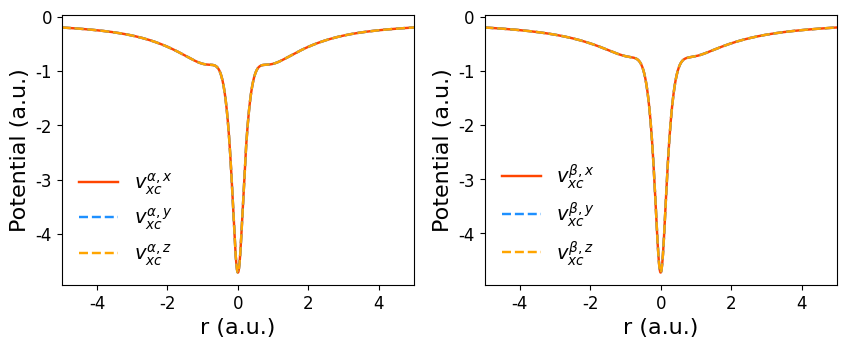

In [33]:
coords_x = gen_coords_1d(-5.0, 5.0, 1000, mode="x")
vx_on_grid_a_x = eval_pot(mf_oep.pmol, coords_x, mf_oep.vrest_oep_a + mf_oep.vref_oep_a)
vx_on_grid_b_x = eval_pot(mf_oep.pmol, coords_x, mf_oep.vrest_oep_b + mf_oep.vref_oep_b)

coords_y = gen_coords_1d(-5.0, 5.0, 1000, mode="y")
vx_on_grid_a_y = eval_pot(mf_oep.pmol, coords_y, mf_oep.vrest_oep_a + mf_oep.vref_oep_a)
vx_on_grid_b_y = eval_pot(mf_oep.pmol, coords_y, mf_oep.vrest_oep_b + mf_oep.vref_oep_b)

coords_z = gen_coords_1d(-5.0, 5.0, 1000)
vx_on_grid_a_z = eval_pot(mf_oep.pmol, coords_z, mf_oep.vrest_oep_a + mf_oep.vref_oep_a)
vx_on_grid_b_z = eval_pot(mf_oep.pmol, coords_z, mf_oep.vrest_oep_b + mf_oep.vref_oep_b)

fig, axs = plt.subplots(1, 2, figsize=(10, 3.5))
axs[0].plot(coords_x[:, 0], vx_on_grid_a_x, color="orangered", label="$v_{xc}^{\\alpha, x}$")
axs[0].plot(coords_y[:, 1], vx_on_grid_a_y, "--", color="dodgerblue", label="$v_{xc}^{\\alpha, y}$")
axs[0].plot(coords_z[:, 2], vx_on_grid_a_z, "--", color="orange", label="$v_{xc}^{\\alpha, z}$")
axs[0].set_xlim(-5, 5)
axs[0].set_ylabel("Potential (a.u.)", fontsize=16)
axs[0].set_xlabel("r (a.u.)", fontsize=16)
axs[0].legend(frameon=False)
axs[1].plot(coords_x[:, 0], vx_on_grid_b_x, color="orangered", label="$v_{xc}^{\\beta, x}$")
axs[1].plot(coords_y[:, 1], vx_on_grid_b_y, "--", color="dodgerblue", label="$v_{xc}^{\\beta, y}$")
axs[1].plot(coords_z[:, 2], vx_on_grid_b_z, "--", color="orange", label="$v_{xc}^{\\beta, z}$")
axs[1].set_xlim(-5, 5)
axs[1].set_ylabel("Potential (a.u.)", fontsize=16)
axs[1].set_xlabel("r (a.u.)", fontsize=16)
axs[1].legend(frameon=False)
plt.show()

### 3.5 Fully-symmetrized calculation for C atom

To restore full symmetry of real electronic system, we can use spin-restricted, i.e. spin-symmetrized, DFT-OEP method with space-symmetrization.

In [34]:
# run DFT calculation
mf = dft.UKS(mol, xc="PBE0").density_fit(auxbasis=DFIT_BASIS).run()

# run DFT-OEP calculation
mf_oep = OSDFTOEP(mf, OEP_BASIS, spin_sym=True, space_sym=True)
mf_oep.run(maxit=30, thr_fai_oep=1.7e-2)

ITER        ENERGY               EDIFF
  0    -37.804275700711
  1    -37.804360390947     -0.000084690236
  2    -37.804333492604      0.000026898343
  3    -37.804328964958      0.000004527646
  4    -37.804328696349      0.000000268608
  5    -37.804328721814     -0.000000025465
  6    -37.804328714225      0.000000007589
SCF converged


In [35]:
print_eigs(mf_oep.mf.mo_energy, mf_oep.nelec, 7)

 1   -10.231  -10.231
 2    -0.688   -0.688
 3    -0.374   -0.374
 4    -0.374   -0.374
 5    -0.374   -0.374
 6    -0.118   -0.118
 7    -0.082   -0.082
HOMO:        -0.374    -0.688
LUMO-HOMO:    0.000     0.314


In [36]:
print(f"S^2 = {mf_oep.mf.spin_square()[0]:.7f}")

S^2 = 2.0000000


The full symmetry of the real electronic system is restored. The orbitals in the $p$-shell exhibit three-fold degeneracy and the same orbitals result for the two spin channels.

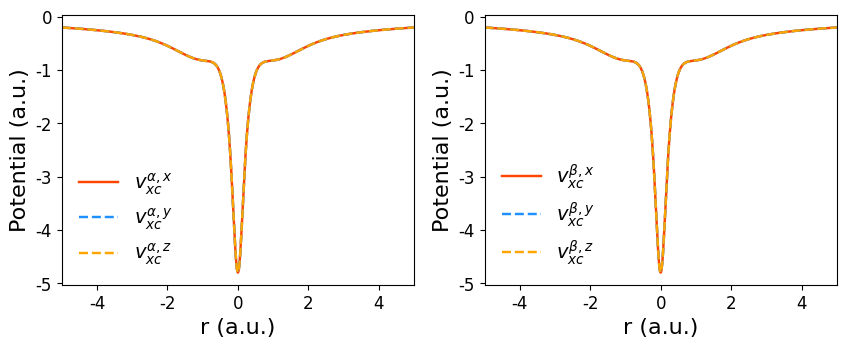

In [37]:
coords_x = gen_coords_1d(-5.0, 5.0, 1000, mode="x")
vx_on_grid_a_x = eval_pot(mf_oep.pmol, coords_x, mf_oep.vrest_oep_a + mf_oep.vref_oep_a)
vx_on_grid_b_x = eval_pot(mf_oep.pmol, coords_x, mf_oep.vrest_oep_b + mf_oep.vref_oep_b)

coords_y = gen_coords_1d(-5.0, 5.0, 1000, mode="y")
vx_on_grid_a_y = eval_pot(mf_oep.pmol, coords_y, mf_oep.vrest_oep_a + mf_oep.vref_oep_a)
vx_on_grid_b_y = eval_pot(mf_oep.pmol, coords_y, mf_oep.vrest_oep_b + mf_oep.vref_oep_b)

coords_z = gen_coords_1d(-5.0, 5.0, 1000)
vx_on_grid_a_z = eval_pot(mf_oep.pmol, coords_z, mf_oep.vrest_oep_a + mf_oep.vref_oep_a)
vx_on_grid_b_z = eval_pot(mf_oep.pmol, coords_z, mf_oep.vrest_oep_b + mf_oep.vref_oep_b)

fig, axs = plt.subplots(1, 2, figsize=(10, 3.5))
axs[0].plot(coords_x[:, 0], vx_on_grid_a_x, color="orangered", label="$v_{xc}^{\\alpha, x}$")
axs[0].plot(coords_y[:, 1], vx_on_grid_a_y, "--", color="dodgerblue", label="$v_{xc}^{\\alpha, y}$")
axs[0].plot(coords_z[:, 2], vx_on_grid_a_z, "--", color="orange", label="$v_{xc}^{\\alpha, z}$")
axs[0].set_xlim(-5, 5)
axs[0].set_ylabel("Potential (a.u.)", fontsize=16)
axs[0].set_xlabel("r (a.u.)", fontsize=16)
axs[0].legend(frameon=False)
axs[1].plot(coords_x[:, 0], vx_on_grid_b_x, color="orangered", label="$v_{xc}^{\\beta, x}$")
axs[1].plot(coords_y[:, 1], vx_on_grid_b_y, "--", color="dodgerblue", label="$v_{xc}^{\\beta, y}$")
axs[1].plot(coords_z[:, 2], vx_on_grid_b_z, "--", color="orange", label="$v_{xc}^{\\beta, z}$")
axs[1].set_xlim(-5, 5)
axs[1].set_ylabel("Potential (a.u.)", fontsize=16)
axs[1].set_xlabel("r (a.u.)", fontsize=16)
axs[1].legend(frameon=False)
plt.show()

### 3.6 TDDFT for Carbon atom

In [38]:
# run DFT calculation
mf = dft.UKS(mol, xc="PBE0").density_fit(auxbasis=DFIT_BASIS).run()

# run DFT-OEP calculation
mf_oep = OSDFTOEP(mf, OEP_BASIS, use_HOMO_condition=True, xc_homo="0.25*HF+0.75*GGA_X_PBE", spin_sym=True, space_sym=True)
mf_oep.run(maxit=30, thr_fai_oep=1.7e-2)

mf_oep.mf.xc="PBE"  # we want to use GGA kernel
td = tddft.TDDFT(mf_oep.mf)
td.nstates = 10
td.kernel()
td.analyze(verbose=10)

ITER        ENERGY               EDIFF
  0    -37.798386423817
  1    -37.804287845294     -0.005901421477
  2    -37.804152313843      0.000135531451
  3    -37.804196535988     -0.000044222145
  4    -37.804210562137     -0.000014026149
  5    -37.804210683929     -0.000000121792
  6    -37.804210676739      0.000000007190
SCF converged

** Excitation energies and oscillator strengths **
Excited State   1:      5.99066 eV    206.96 nm  f=0.0001
       2a ->    5a     -0.64075
       2b ->    5b      0.78330
Excited State   2:      7.64087 eV    162.26 nm  f=0.1075
       3a ->    6a     -0.93088
       2b ->    3b      0.35825
Excited State   3:      7.64088 eV    162.26 nm  f=0.1075
       4a ->    6a     -0.93088
       2b ->    4b      0.35825
Excited State   4:      8.40442 eV    147.52 nm  f=0.0132
       3a ->    6a     -0.36389
       3a ->   10a     -0.15574
       4a ->   14a     -0.12212
       2b ->    3b     -0.89477
Excited State   5:      8.40442 eV    147.52 nm  f=0.01

## 4. Concluding remarks
In this tutorial, we explored density functional theory optimized effective potential calculations for closed- and open-shell systems.

For open-shell systems, in addition to the standard spin-unrestricted DFT-OEP method, we looked at the spin-restricted DFT-OEP method, which preserves the correct spin symmetry of a real electronic system. For both spin-unrestricted and spin-restricted DFT-OEP methods, we also performed calculations with additional space-symmetrization, which forces the KS system to have the correct spatial symmetry of a real electronic system.

We considered an option to enforce an additional condition for the exchange-correlation potential, the so-called HOMO condition.

Examples of TDDFT calculations for closed- and open-shell cases were presented.

As a post-processing of calculations, we accessed and printed orbital energies and explored how to plot the resulting exchange potential and its individual contributions.

---

[![Ask questions](https://img.shields.io/static/v1.svg?logo=star&label=❔&message=Ask%20Questions&color=9cf)](https://github.com/EgorTrushin/PyOEP/issues)  For any questions, typos, or bugs that you found, please raise an issue on GitHub.  
[![Star the repository](https://img.shields.io/static/v1.svg?logo=star&label=⭐&message=Star%20the%20Repository&color=yellow)](https://github.com/EgorTrushin/PyOEP/)  If you found this tutorial helpful, consider ⭐-ing the repository.